Dataset loaded successfully. Shape: (5, 60, 16)
Dataset detected: 1 trials, 60 timesteps, 16 neurons.

--- Model Fitting Matrix Shapes ---
A (Hidden Transitions)    : (16, 16)
B (Input Mapping)         : (16, 2)
C (Observation Mapping)   : (16, 16)
Q (Process Noise Cov)     : (16, 16)
R (Measurement Noise Cov) : (16, 16)
Starting Seed Vector      : (16,)

Generated fake data matrix shape: (5, 61, 16)


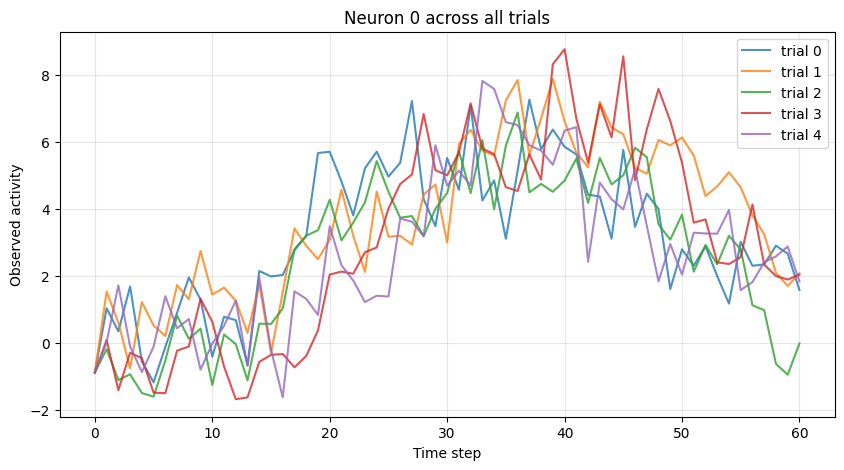

c:\Development\GG4\Illustrator_two.py:612: RuntimeWarning: invalid value encountered in divide
  bar_colours = plt.cm.plasma(var_per_neuron / var_per_neuron.max())


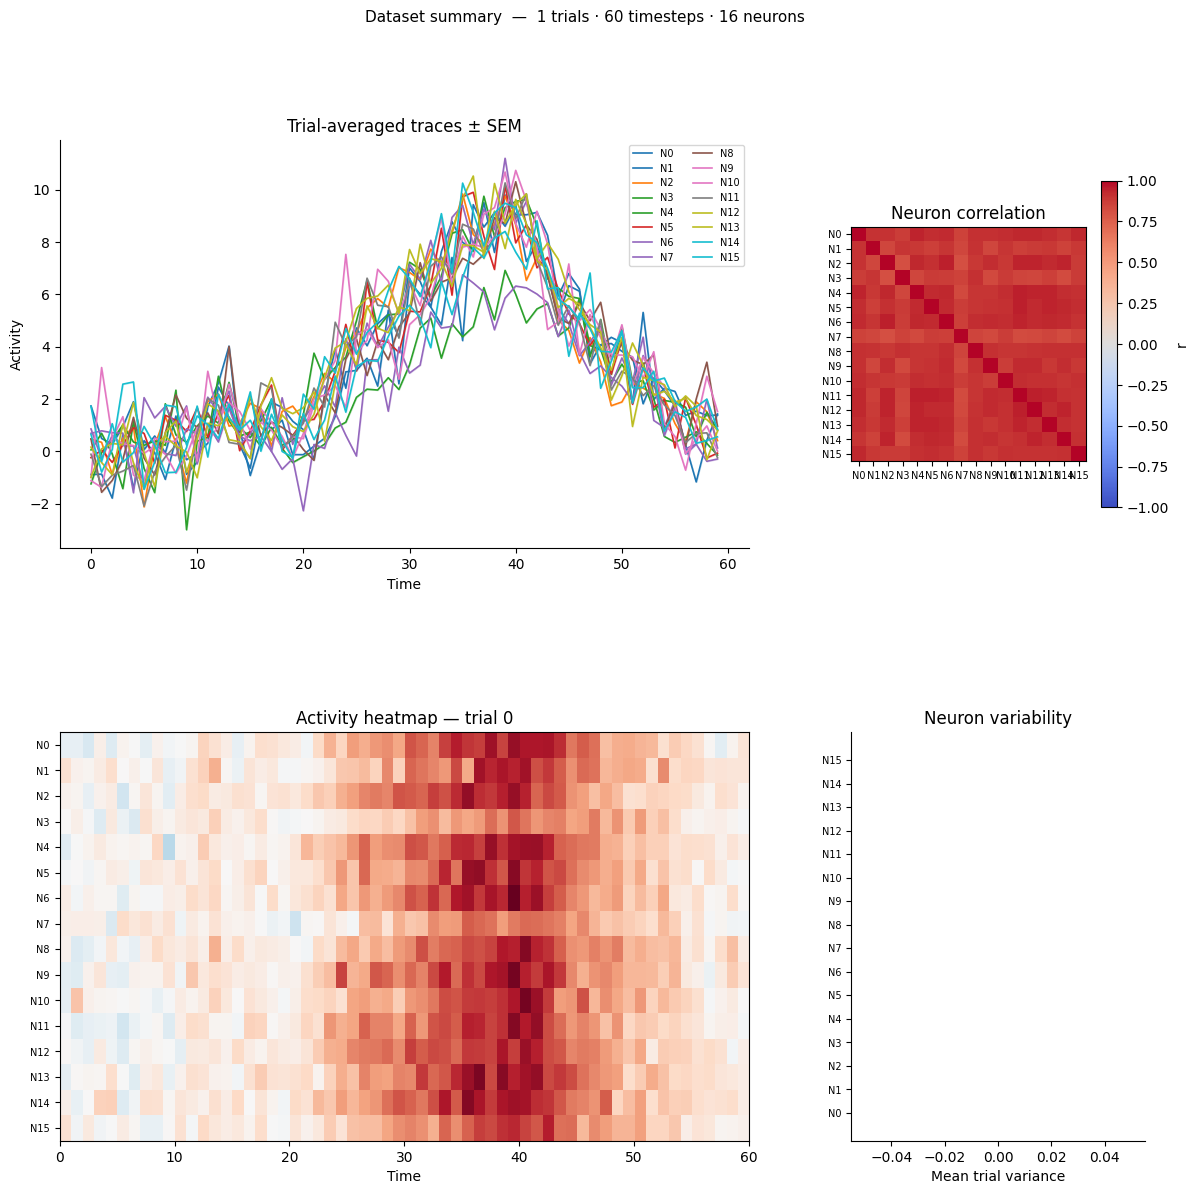

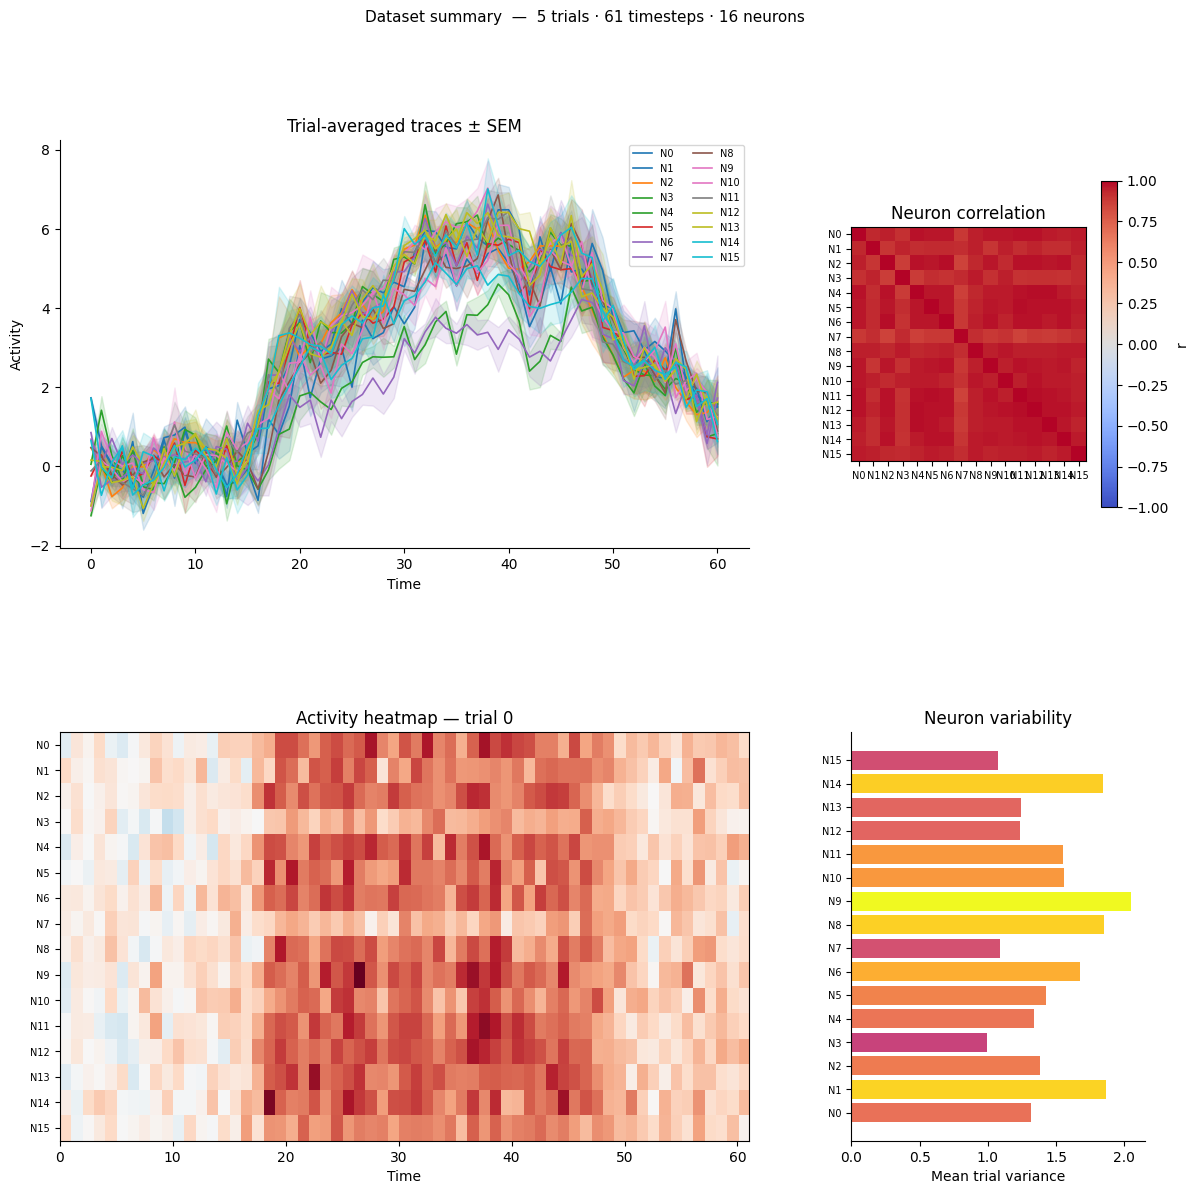

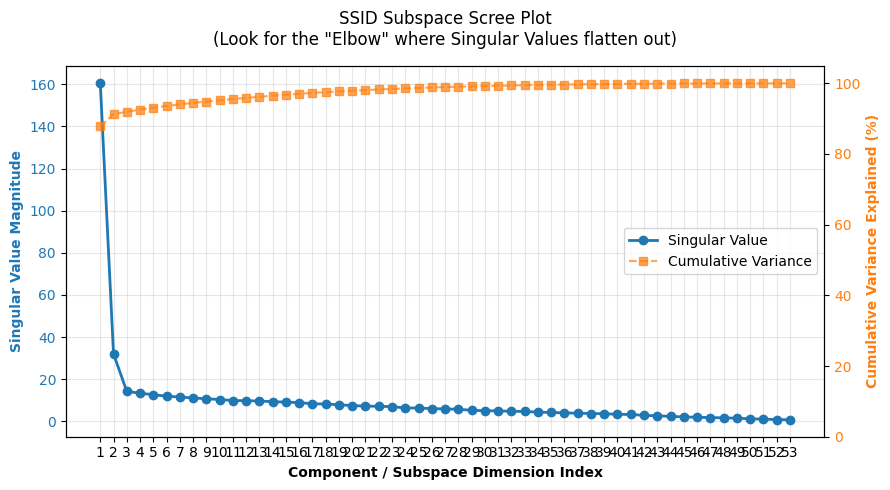

In [ ]:
import numpy as np
from Illustrator_Hassan import Illustrator
from Illustrator_two import Illustrator_two
from Simulator import Simulator
data = np.load("ExampleDataset.npy")
print("Dataset loaded successfully. Shape:", data.shape)  # (Trials, Timepoints, Neurons) - so we batch 
data = np.array([data[0]])
# =====================================================================
# PIPELINE EXECUTION FOR 'data'
# =====================================================================

# 1. Instantiate your Illustrator class with your dataset
ill = Illustrator(data)

print(f"Dataset detected: {ill.trial_cnt} trials, {ill.timestep_cnt} timesteps, {ill.neuron_cnt} neurons.")

# 2. Define your external input properties (e.g., a pulse from step 15 to 45)
pulse_start = 15
pulse_end = 45
input_dimensions = 2  # 1D control signal

# Generate the base 1D pulse using the class's static method
base_pulse = Illustrator.generate_pulse(
    length=ill.timestep_cnt, 
    start_time=pulse_start, 
    end_time=pulse_end, 
    input_dim=input_dimensions
)

# Broadcast the pulse across all trials to match the shape: (Trials, Timesteps, Input_Dims)
U_sequence = np.tile(base_pulse, (ill.trial_cnt, 1, 1))


# 3. Choose your target hidden state dimension and fit the entire system
# (e.g., state_dim=3 compresses your neurons into a 3-dimensional dynamic engine)
target_states = 1
A, B, C, Q, R, starting_seed = ill.fit_full_system(U=U_sequence, state_dim=target_states)


# 4. Safeguard: Force Q and R to stay 2D matrices (prevents scalar errors if state_dim=1)
Q = np.atleast_2d(Q)
R = np.atleast_2d(R)


# =====================================================================
# DISPLAY THE IDENTIFIED PARAMETERS
# =====================================================================

print("\n--- Model Fitting Matrix Shapes ---")
print(f"A (Hidden Transitions)    : {A.shape}")
print(f"B (Input Mapping)         : {B.shape}")
print(f"C (Observation Mapping)   : {C.shape}")
print(f"Q (Process Noise Cov)     : {Q.shape}")
print(f"R (Measurement Noise Cov) : {R.shape}")
print(f"Starting Seed Vector      : {starting_seed.shape}\n")


# Pack the estimated variables into the structural list your Simulator expects
sim_parameters = [A, B, C, Q, R]
simulator = Simulator(sim_parameters)

# Define the control callback function to feed the current pulse step into the loop
def bp(time, history_data):
    """
    Safely indexes into Trial 0 of the pulse input sequence 
    for the current simulation timestep.
    """
    return U_sequence[0, time, :]

# Generate the synthetic data matching the fit profile
# Here we simulate 5 trials, tracking a length of 60 timesteps
fake_data = simulator.generate_data(
    trials=5,
    lengths=60,
    seed=starting_seed,
    control_function=bp
)


# =====================================================================
# 3. VISUALIZE SYNTHETIC RESULTS
# =====================================================================

# Pack your simulated data back into the Illustrator layout to check the result
fake_ill = Illustrator(fake_data)

print(f"Generated fake data matrix shape: {fake_data.shape}")

# Plot Neuron 0's profile to verify the simulated pulse response matches expectations
fake_ill.plot_neuron(neuron_id=0)
claude_illustrator = Illustrator_two(data)
fake_claude_illustrator = Illustrator_two(fake_data)
claude_illustrator.summary_dashboard()
fake_claude_illustrator.summary_dashboard()
ill.plot_scree()